In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from natsort import natsorted
import matplotlib as mpl

# Add function path
original_path = os.getcwd()
os.chdir(original_path)
function_path = '../functions/'
sys.path.append(function_path)

# Import custom functions
from analysis_function import *
from kcc_constrain_function import *
from Plot_function import *
from f1_0_H_sum_multi_region_constrain import *
from f_IMP import *
from f_schemes import *

In [5]:
path = '../saved_data/'
file_name = '2.0.real_obs_constrain_prior_post_warming_2016-2025_ref.1850-1900.nc'
prior_post_warm = xr.open_dataarray(path + file_name) 

file_name = '2.1.real_obs_constrain_prior_post_smoothed_series_1850-2025_ref.1850-1900.nc'
prior_post_smooth = xr.open_dataarray(path + file_name) 


def load_xr_pickle(filename):
    with open(filename, "rb") as f:
        return pickle.load(f)

obs_adj_ALL_ref1850 = load_xr_pickle(path + '2.3_adjust_obs_warming_ref1850_1850-2100.pkl')




In [6]:
obs_adj_ALL_ref1850

<xarray.DataArray 'obs_adjusted' (region: 47, forcing: 1, year: 251)> Size: 94kB
array([[[nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan]],

       ...,

       [[nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan]]], shape=(47, 1, 251))
Coordinates:
  * region       (region) int64 376B 0 1 2 3 4 5 6 7 ... 39 40 41 42 43 44 45 46
  * year         (year) int64 2kB 1850 1851 1852 1853 ... 2097 2098 2099 2100
  * forcing      (forcing) <U3 12B 'ALL'
    abbrevs      (region) <U4 752B 'GIC' 'NWN' 'NEN' ... 'EAN' 'WAN' 'LSAT'
    names        (region) <U25 5kB 'Greenland/Iceland' ... 'Global Land'
    realization  int64 8B 100

In [7]:
prior_post_smooth.sel(scheme = 'post', quantile = 'mean')

<xarray.DataArray 'prior_mean_5_95_smooth' (region: 47, forcing: 5, year: 176)> Size: 331kB
[41360 values with dtype=float64]
Coordinates:
  * region       (region) int64 376B 0 1 2 3 4 5 6 7 ... 39 40 41 42 43 44 45 46
  * year         (year) int64 1kB 1850 1851 1852 1853 ... 2022 2023 2024 2025
  * forcing      (forcing) <U3 60B 'ALL' 'ANT' 'NAT' 'GHG' 'OA'
    quantile     <U4 16B 'mean'
    abbrevs      (region) <U4 752B ...
    names        (region) <U22 4kB ...
    realization  int64 8B ...
    scheme       <U5 20B 'post'

In [8]:
from scipy.stats import pearsonr

# Select the observed ALL-forcing series and the posterior mean.
obs_all = obs_adj_ALL_ref1850.sel(forcing='ALL', drop=True)
post_mean = prior_post_smooth.sel(scheme='post', quantile='mean')

# Restrict both arrays to their shared region/year coordinates.
obs_all, post_mean = xr.align(obs_all, post_mean, join='inner')

# Each region has its own valid-observation years. This (region, year)
# mask broadcasts across all forcings in post_mean.
obs_valid_mask = obs_all.notnull()
post_mean_obs_years = post_mean.where(obs_valid_mask)

# Pearson correlation over the valid years, for every region and forcing.
corr_region_forcing = xr.corr(
    post_mean_obs_years, obs_all, dim='year'
).rename('pearson_r')
n_obs_years = obs_valid_mask.sum('year').rename('n_obs_years')

# Do not report correlations for regions with fewer than 30 observed years.
corr_region_forcing = corr_region_forcing.where(n_obs_years >= 30)

# Nominal two-sided Pearson p values (p < 0.05) for the displayed correlations.
alpha = 0.05
p_values = xr.full_like(corr_region_forcing, np.nan, dtype=float).rename('pearson_p')
for region in corr_region_forcing.region.values:
    valid_years = obs_valid_mask.sel(region=region).values
    if valid_years.sum() < 30:
        continue

    obs_values = obs_all.sel(region=region).values[valid_years]
    for forcing in corr_region_forcing.forcing.values:
        post_values = post_mean.sel(region=region, forcing=forcing).values[valid_years]
        finite = np.isfinite(obs_values) & np.isfinite(post_values)
        if finite.sum() >= 3:
            p_values.loc[dict(region=region, forcing=forcing)] = pearsonr(
                obs_values[finite], post_values[finite]
            ).pvalue

significant = (p_values < alpha).rename('pearson_significant')

def region_labels(mask):
    return [
        f"{corr_region_forcing['abbrevs'].sel(region=region).item()} "
        f"({corr_region_forcing['names'].sel(region=region).item()})"
        for region in corr_region_forcing.region.where(mask, drop=True).values
    ]

all_not_significant = (p_values.sel(forcing='ALL') >= alpha)
nat_significant = significant.sel(forcing='NAT')
print('ALL, nominally not significant (p >= 0.05):', region_labels(all_not_significant))
print('NAT, nominally significant (p < 0.05):', region_labels(nat_significant))

corr_results = xr.Dataset({
    'pearson_r': corr_region_forcing,
    'pearson_p': p_values,
    'pearson_significant': significant,
    'n_obs_years': n_obs_years,
})

bias = (obs_all - post_mean_obs_years).mean('year').rename('bias_mean')



ALL, nominally not significant (p >= 0.05): []
NAT, nominally significant (p < 0.05): ['WNA (W.North-America)', 'CNA (C.North-America)', 'ENA (E.North-America)', 'NCA (N.Central-America)', 'CAR (Caribbean)', 'NWS (N.W.South-America)', 'SES (S.E.South-America)', 'SSA (S.South-America)', 'MED (Mediterranean)', 'NEAF (N.Eastern-Africa)', 'WSAF (W.Southern-Africa)', 'ESAF (E.Southern-Africa)', 'MDG (Madagascar)', 'WSB (W.Siberia)', 'ESB (E.Siberia)', 'RFE (Russian-Far-East)', 'TIB (Tibetan-Plateau)', 'ARP (Arabian-Peninsula)', 'CAU (C.Australia)', 'EAU (E.Australia)', 'SAU (S.Australia)', 'NZ (New-Zealand)']


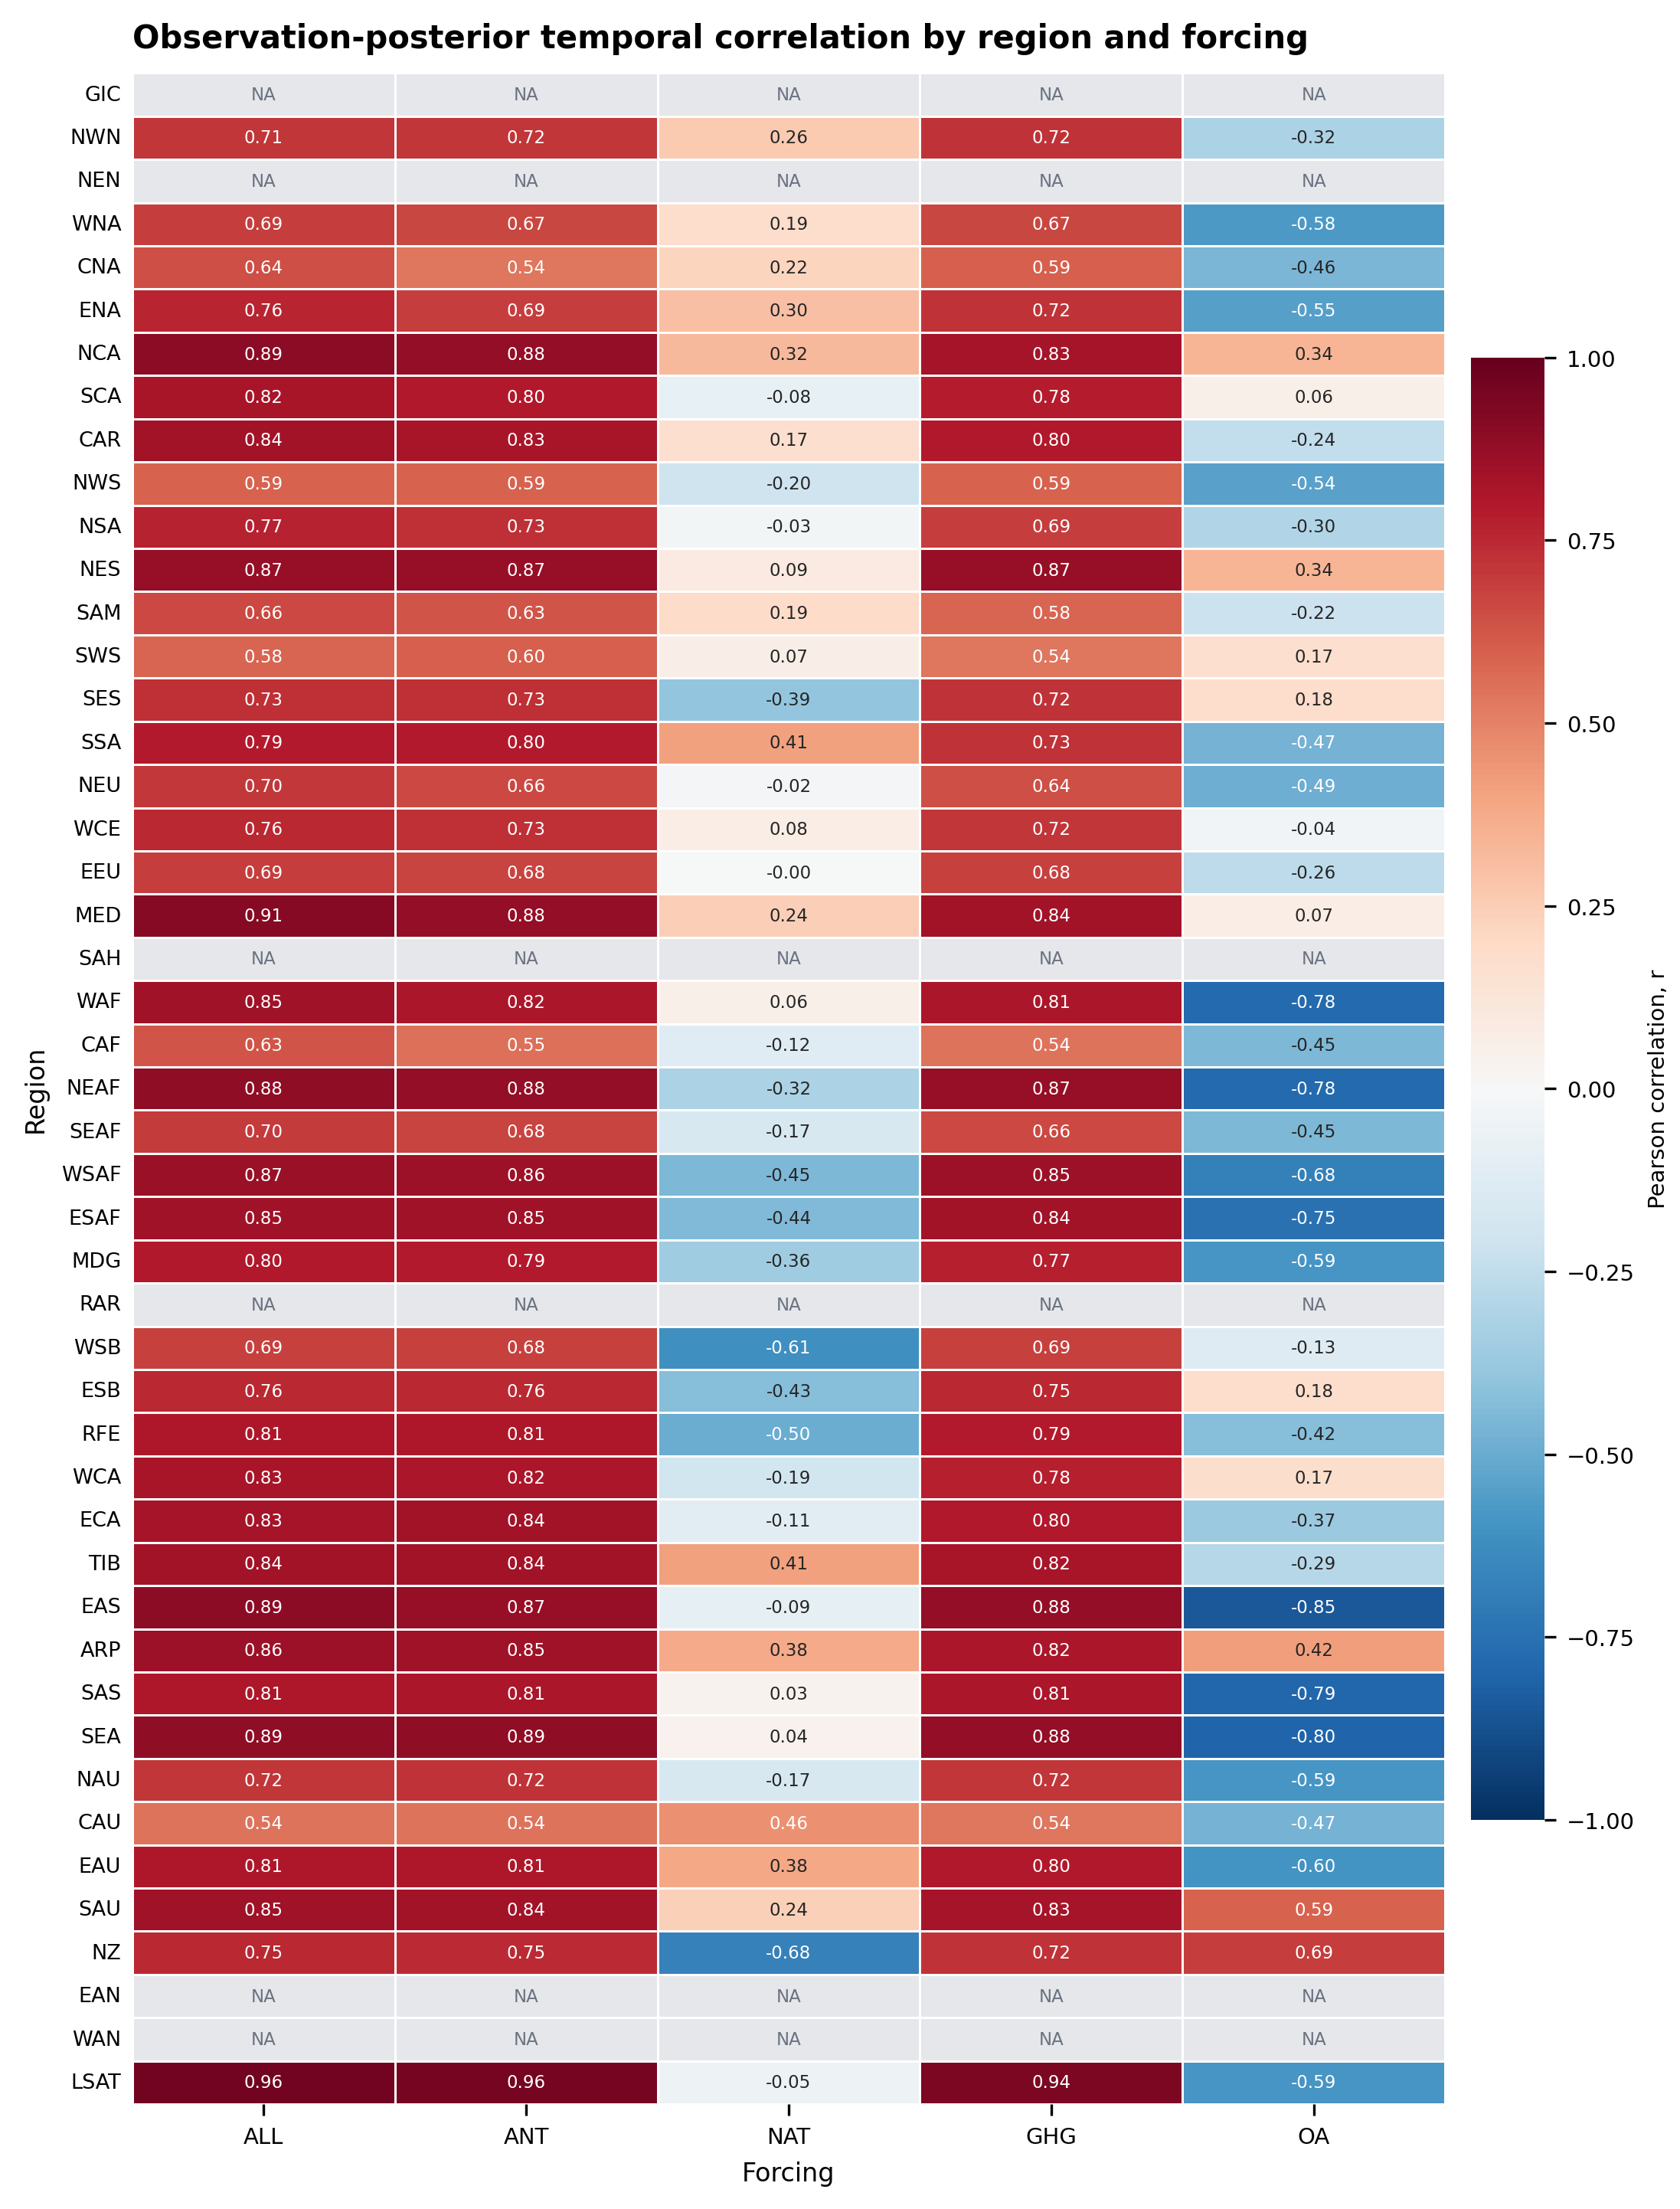

In [9]:
# Heatmap of regional correlations for all forcings.
corr_plot = corr_results['pearson_r'].transpose('region', 'forcing')
region_labels = (
    corr_plot['abbrevs'].values
    if 'abbrevs' in corr_plot.coords
    else corr_plot['region'].values.astype(str)
)

cmap = mpl.colormaps['RdBu_r'].copy()
cmap.set_bad('#E5E7EB')

with mpl.rc_context({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 7,
    'svg.fonttype': 'none',
    'pdf.fonttype': 42,
}):
    fig, ax = plt.subplots(figsize=(7.2, 9.5), dpi = 300, constrained_layout=True)
    sns.heatmap(
        corr_plot.values,
        ax=ax,
        cmap=cmap,
        vmin=-1,
        vmax=1,
        center=0,
        annot=True,
        fmt='.2f',
        annot_kws={'fontsize': 5.5},
        linewidths=0.35,
        linecolor='white',
        xticklabels=corr_plot['forcing'].values,
        yticklabels=region_labels,
        cbar_kws={
            'label': 'Pearson correlation, r',
            'shrink': 0.72,
            'pad': 0.02,
        },
    )

    # Make missing correlations explicit instead of leaving blank cells.
    for row, col in zip(*np.where(corr_plot.isnull().values)):
        ax.text(
            col + 0.5, row + 0.5, 'NA',
            ha='center', va='center', fontsize=5.5, color='#6B7280'
        )

    ax.set_title(
        'Observation-posterior temporal correlation by region and forcing',
        loc='left', fontsize=10, fontweight='bold', pad=8,
    )
    ax.set_xlabel('Forcing', fontsize=8)
    ax.set_ylabel('Region', fontsize=8)
    ax.tick_params(axis='x', rotation=0, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=6.5, length=0)

plt.show()

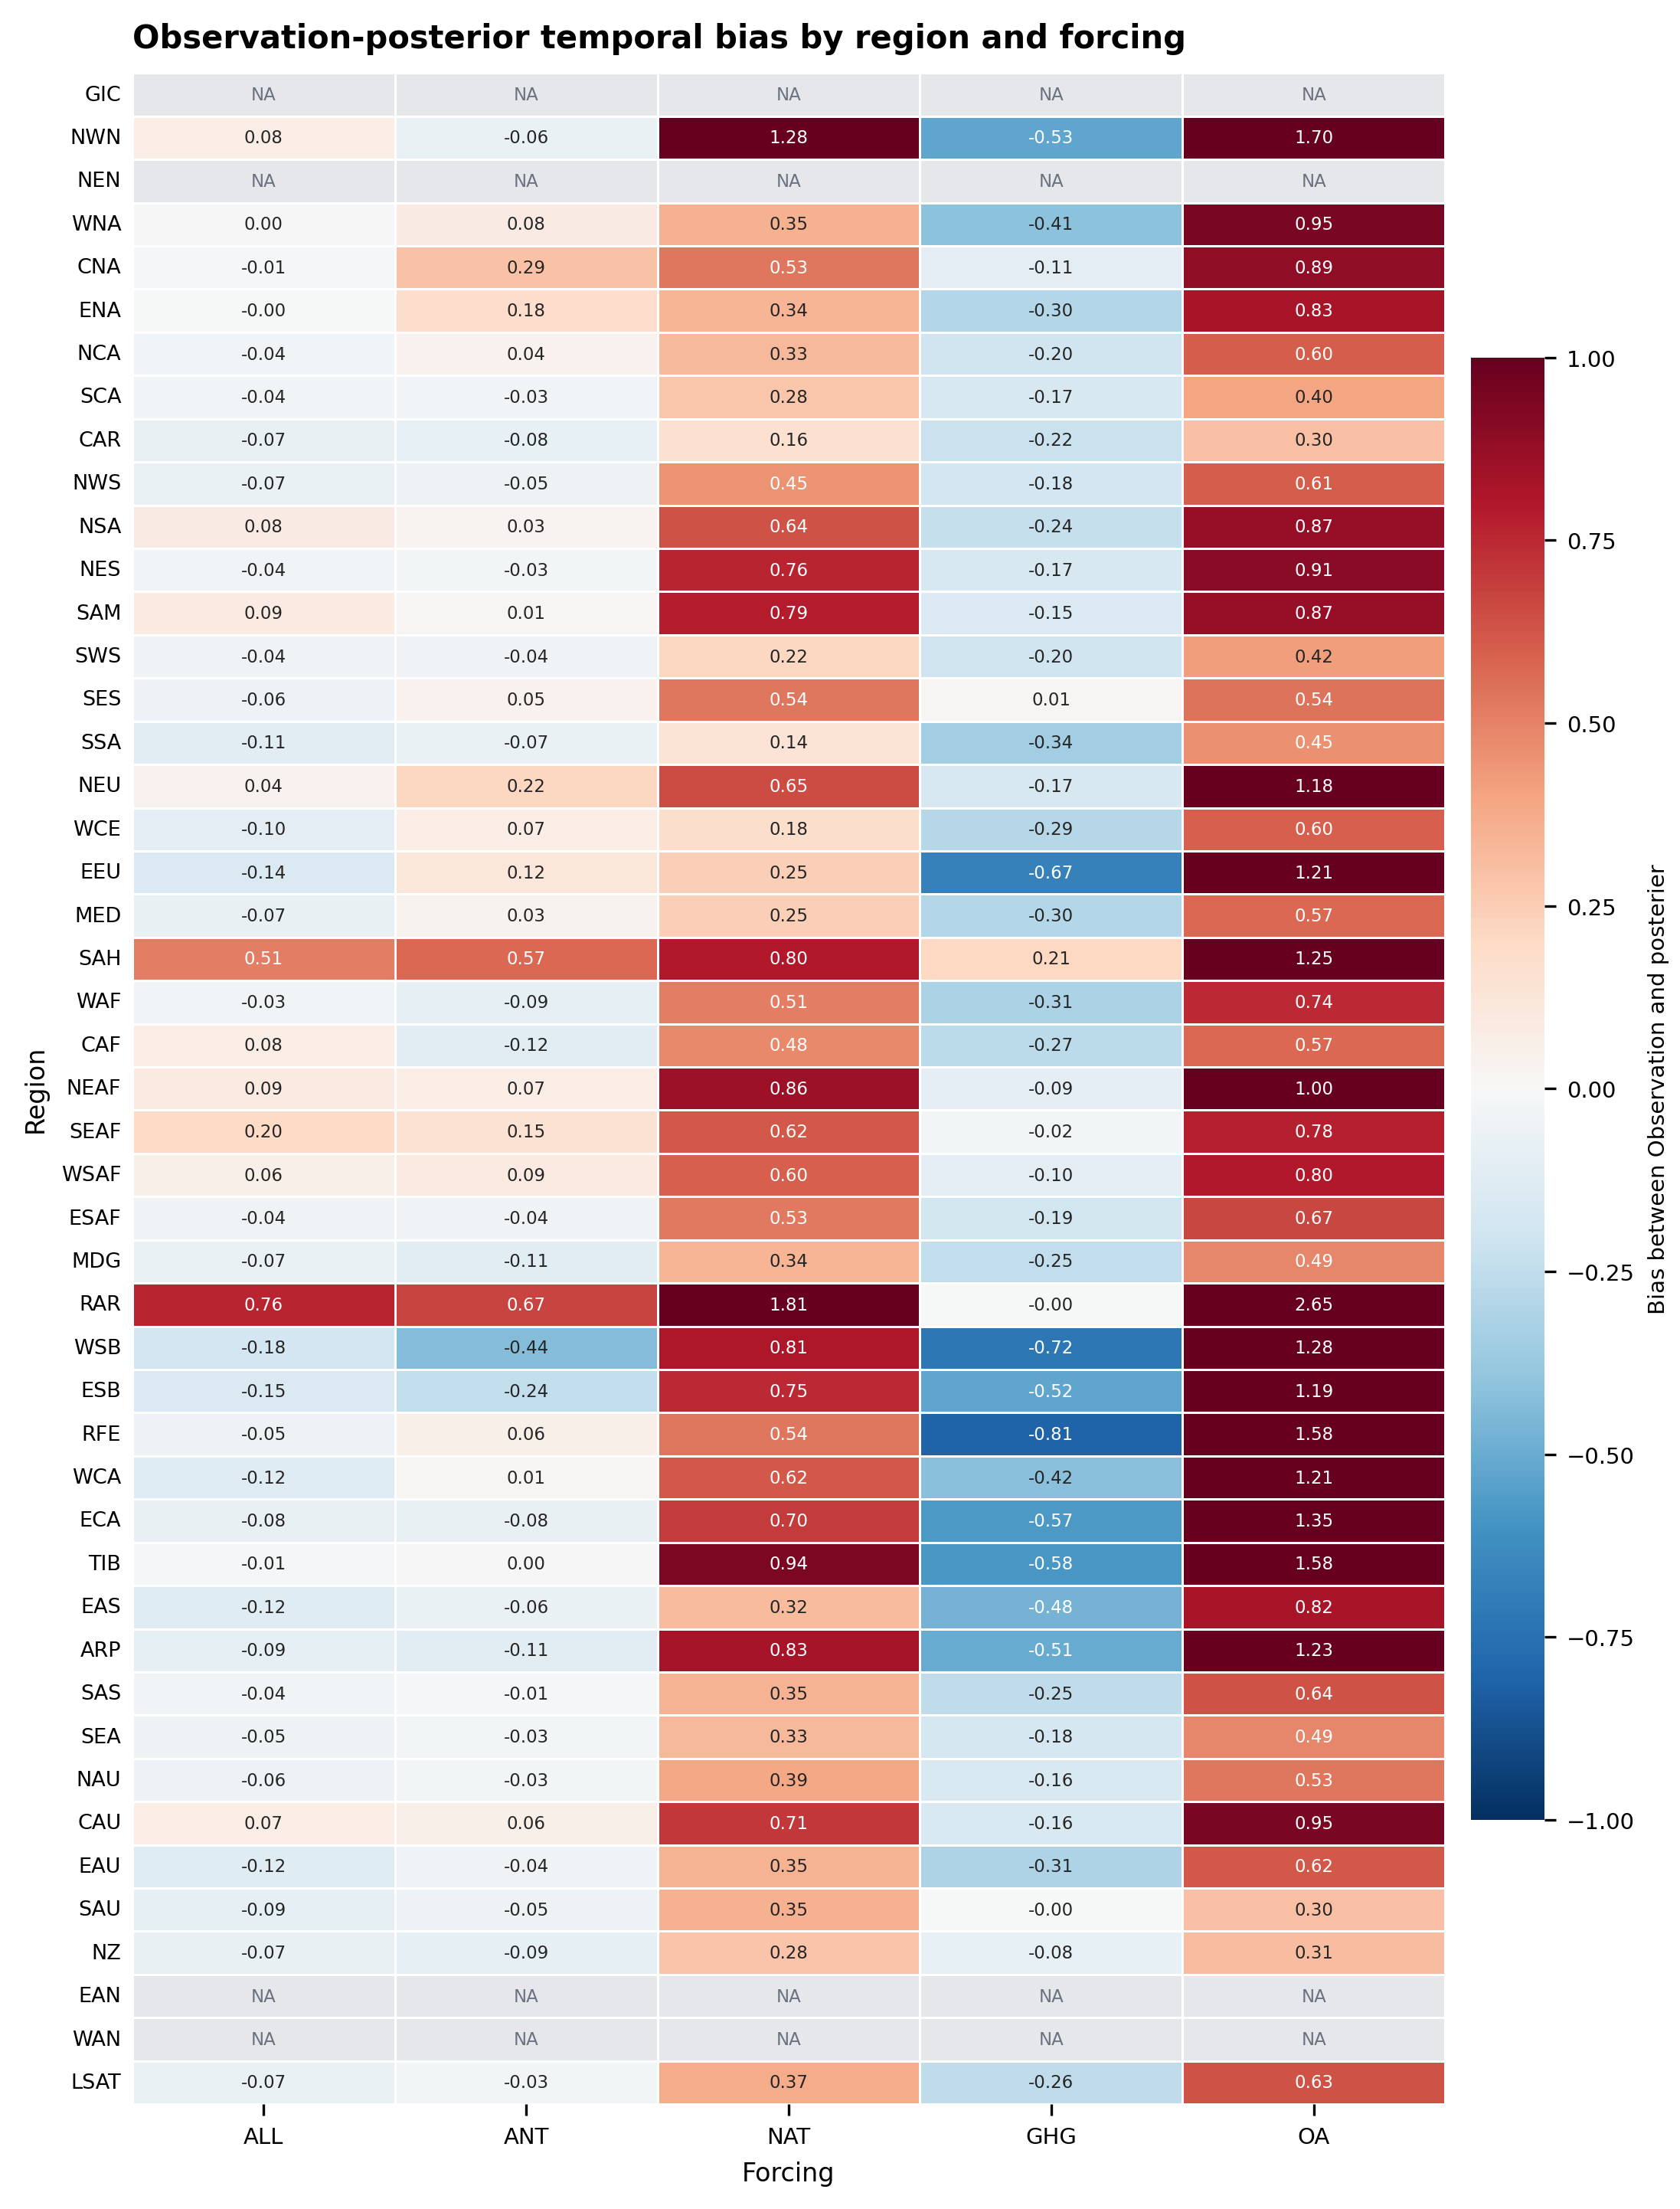

In [10]:
# Heatmap of regional biaselations for all forcings.
bias_plot = bias.transpose('region', 'forcing')
region_labels = (
    bias_plot['abbrevs'].values
    if 'abbrevs' in bias_plot.coords
    else bias_plot['region'].values.astype(str)
)

cmap = mpl.colormaps['RdBu_r'].copy()
cmap.set_bad('#E5E7EB')

with mpl.rc_context({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 7,
    'svg.fonttype': 'none',
    'pdf.fonttype': 42,
}):
    fig, ax = plt.subplots(figsize=(7.2, 9.5), dpi = 300, constrained_layout=True)
    sns.heatmap(
        bias_plot.values,
        ax=ax,
        cmap=cmap,
        vmin=-1,
        vmax=1,
        center=0,
        annot=True,
        fmt='.2f',
        annot_kws={'fontsize': 5.5},
        linewidths=0.35,
        linecolor='white',
        xticklabels=bias_plot['forcing'].values,
        yticklabels=region_labels,
        cbar_kws={
            'label': 'Bias between Observation and posterier',
            'shrink': 0.72,
            'pad': 0.02,
        },
    )

    # Make missing biaselations explicit instead of leaving blank cells.
    for row, col in zip(*np.where(bias_plot.isnull().values)):
        ax.text(
            col + 0.5, row + 0.5, 'NA',
            ha='center', va='center', fontsize=5.5, color='#6B7280'
        )

    ax.set_title(
        'Observation-posterior temporal bias by region and forcing',
        loc='left', fontsize=10, fontweight='bold', pad=8,
    )
    ax.set_xlabel('Forcing', fontsize=8)
    ax.set_ylabel('Region', fontsize=8)
    ax.tick_params(axis='x', rotation=0, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=6.5, length=0)

plt.show()

In [11]:
# bias_correction = np.abs(prior_post_warm.sel(forcing = 'ALL',quantile = 'mean').sel(scheme = 'post') - prior_post_warm.sel(forcing = 'ALL',quantile = 'mean').sel(scheme = 'prior'))
bias_correction = prior_post_warm.sel(forcing = 'ALL',quantile = 'mean').sel(scheme = 'post') - prior_post_warm.sel(forcing = 'ALL',quantile = 'mean').sel(scheme = 'prior')

uncertainty_reduction = (prior_post_warm.sel(forcing = 'ALL', quantile = '95th') - prior_post_warm.sel(forcing = 'ALL', quantile = '5th')).sel(scheme = 'prior') - (prior_post_warm.sel(forcing = 'ALL', quantile = '95th') - prior_post_warm.sel(forcing = 'ALL', quantile = '5th')).sel(scheme = 'post')

print(bias_correction)

<xarray.DataArray 'prior_warming' (region: 47)> Size: 376B
array([ 0.02147629,  0.14338675,  0.12165005, -0.04829127,  0.20740755,
        0.07762219,  0.11487922, -0.03604618, -0.03045843, -0.09615146,
       -0.09750841,  0.19355265, -0.22135977, -0.24883191, -0.01272602,
        0.10459423, -0.09295246,  0.47144267,  0.25679953,  0.22057632,
        0.00711545,  0.14864903, -0.1963817 ,  0.45010849,  0.03365191,
        0.17931019,  0.12663043,  0.01601942,  0.33568654,  0.00914012,
        0.31712358, -0.28809796,  0.33118237,  0.08143116,  0.32404423,
        0.44826454,  0.05361938,  0.26325995,  0.04700068, -0.05049908,
       -0.04695925,  0.14951579,  0.22545146,  0.06906087, -0.03486878,
       -0.01826229,  0.05014762])
Coordinates:
  * region       (region) int64 376B 0 1 2 3 4 5 6 7 ... 39 40 41 42 43 44 45 46
    forcing      <U3 12B 'ALL'
    quantile     <U4 16B 'mean'
    abbrevs      (region) <U4 752B 'GIC' 'NWN' 'NEN' ... 'EAN' 'WAN' 'LSAT'
    names        (region) 

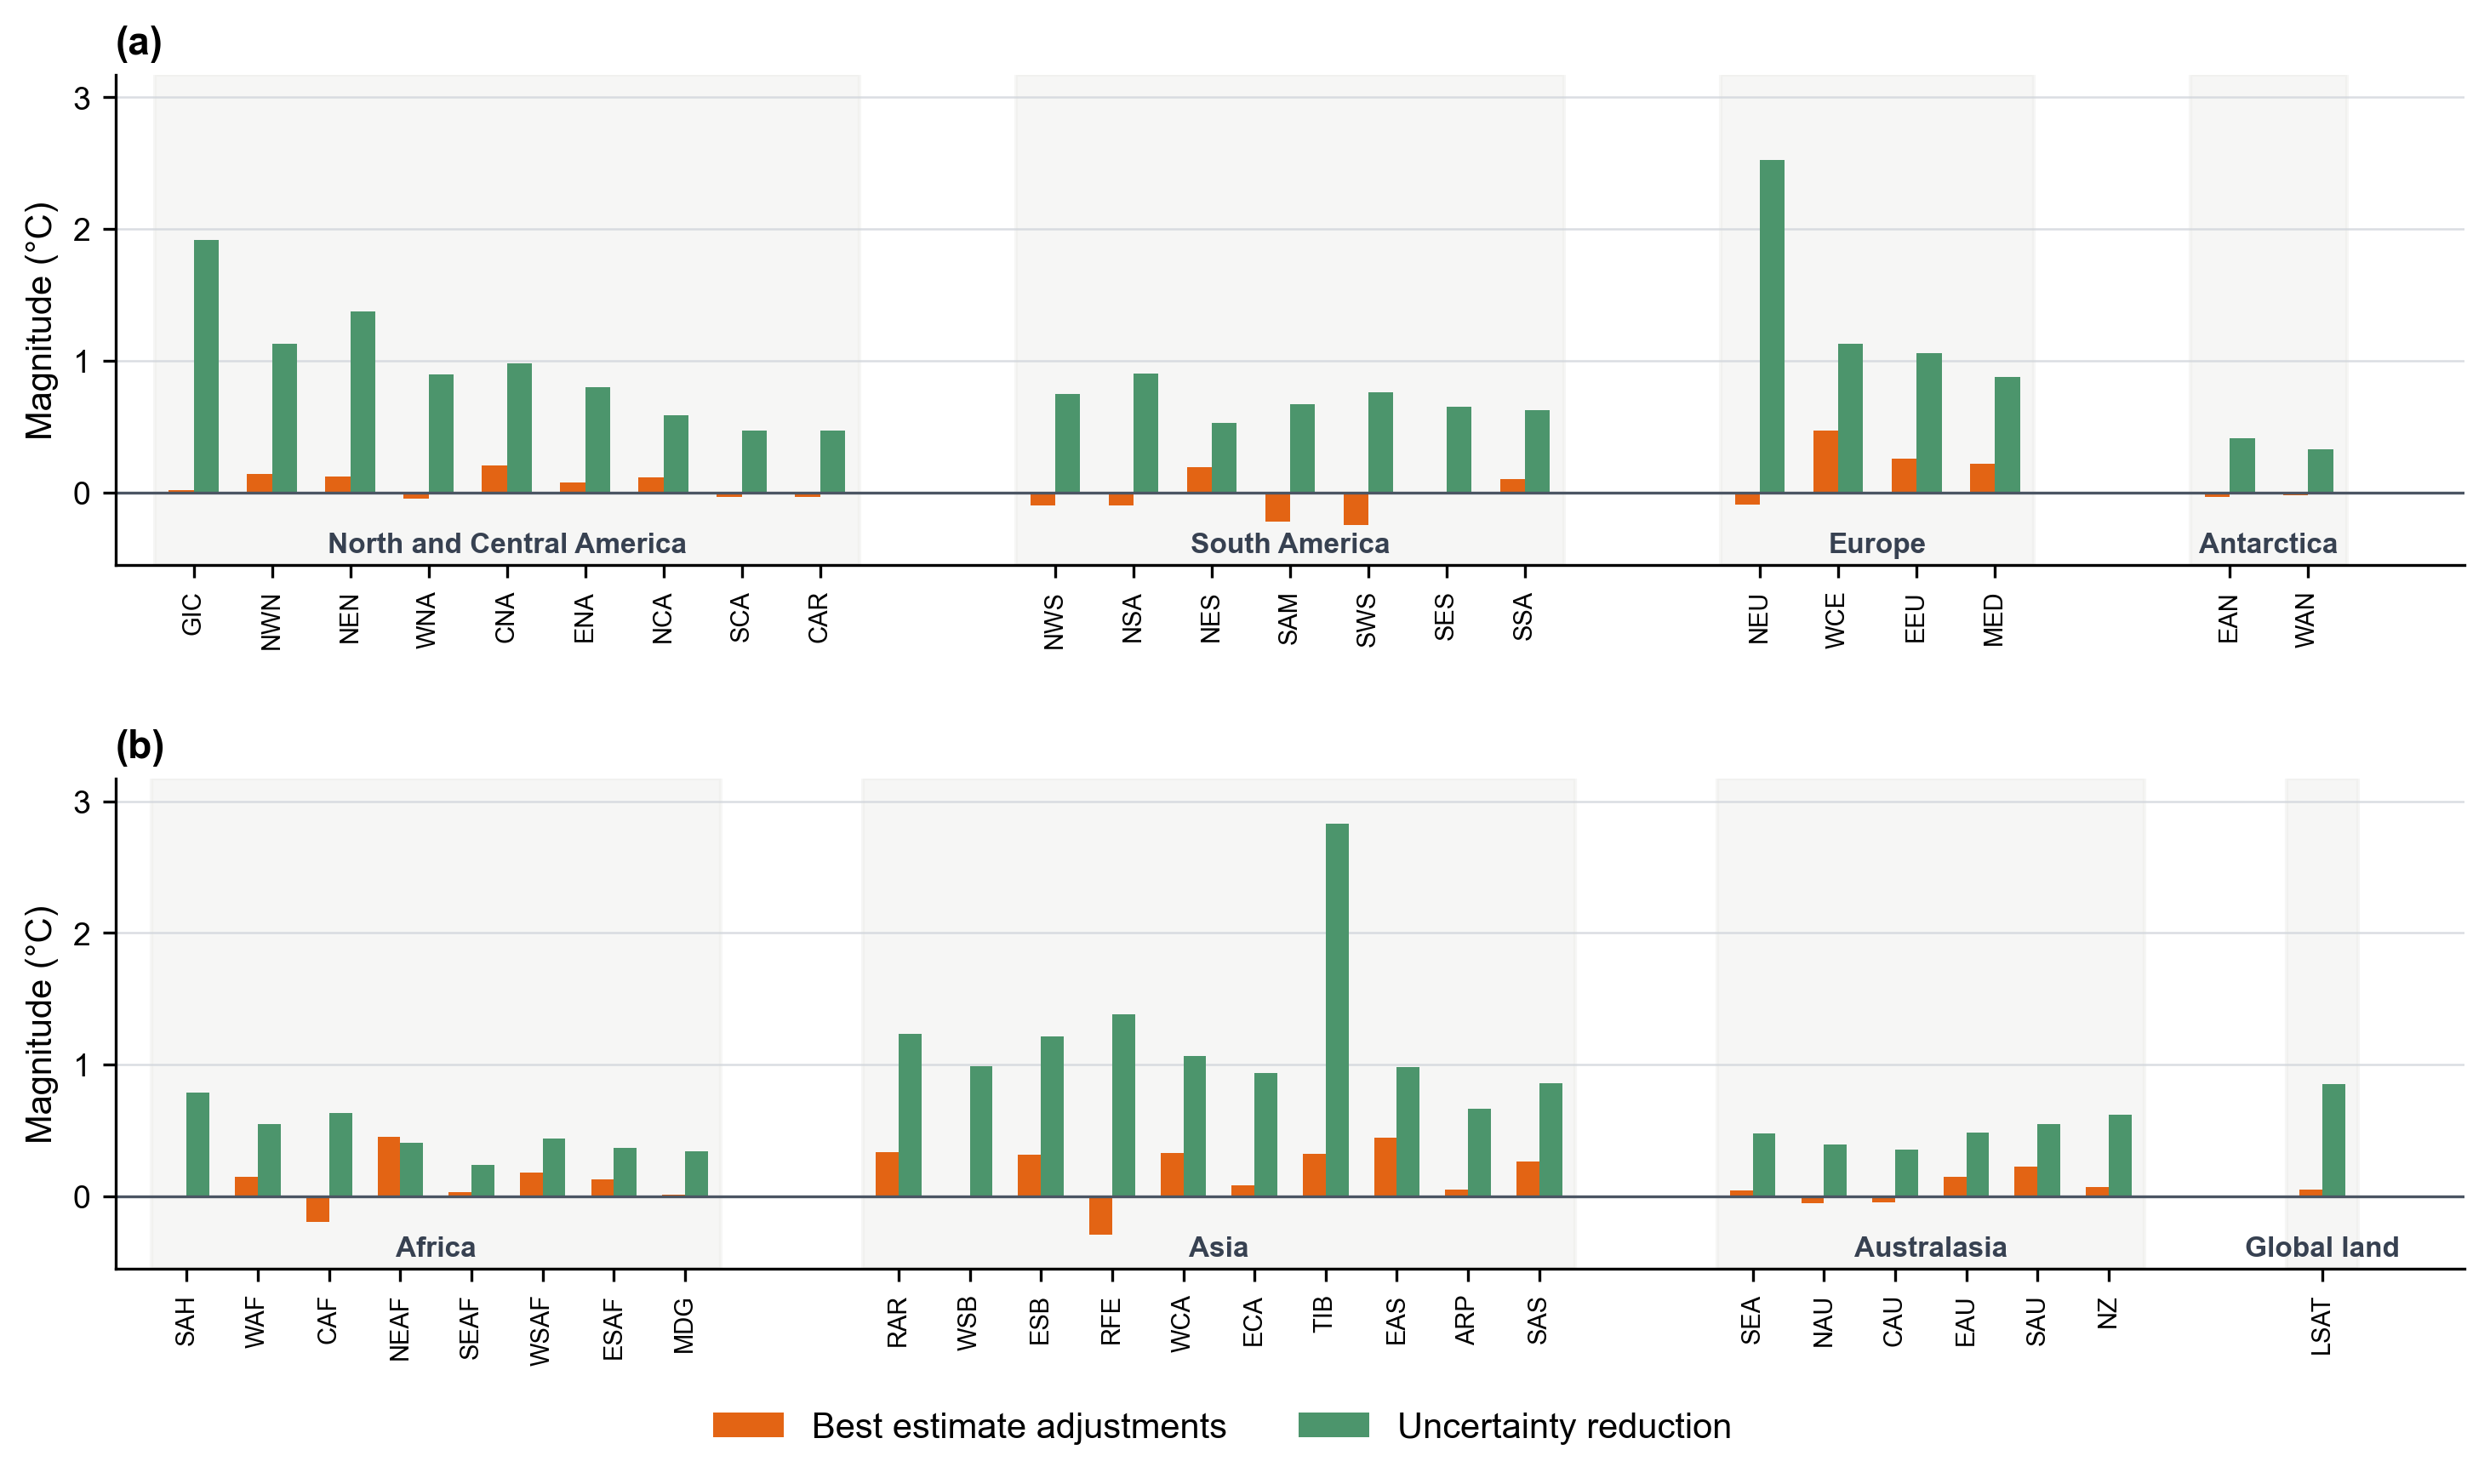

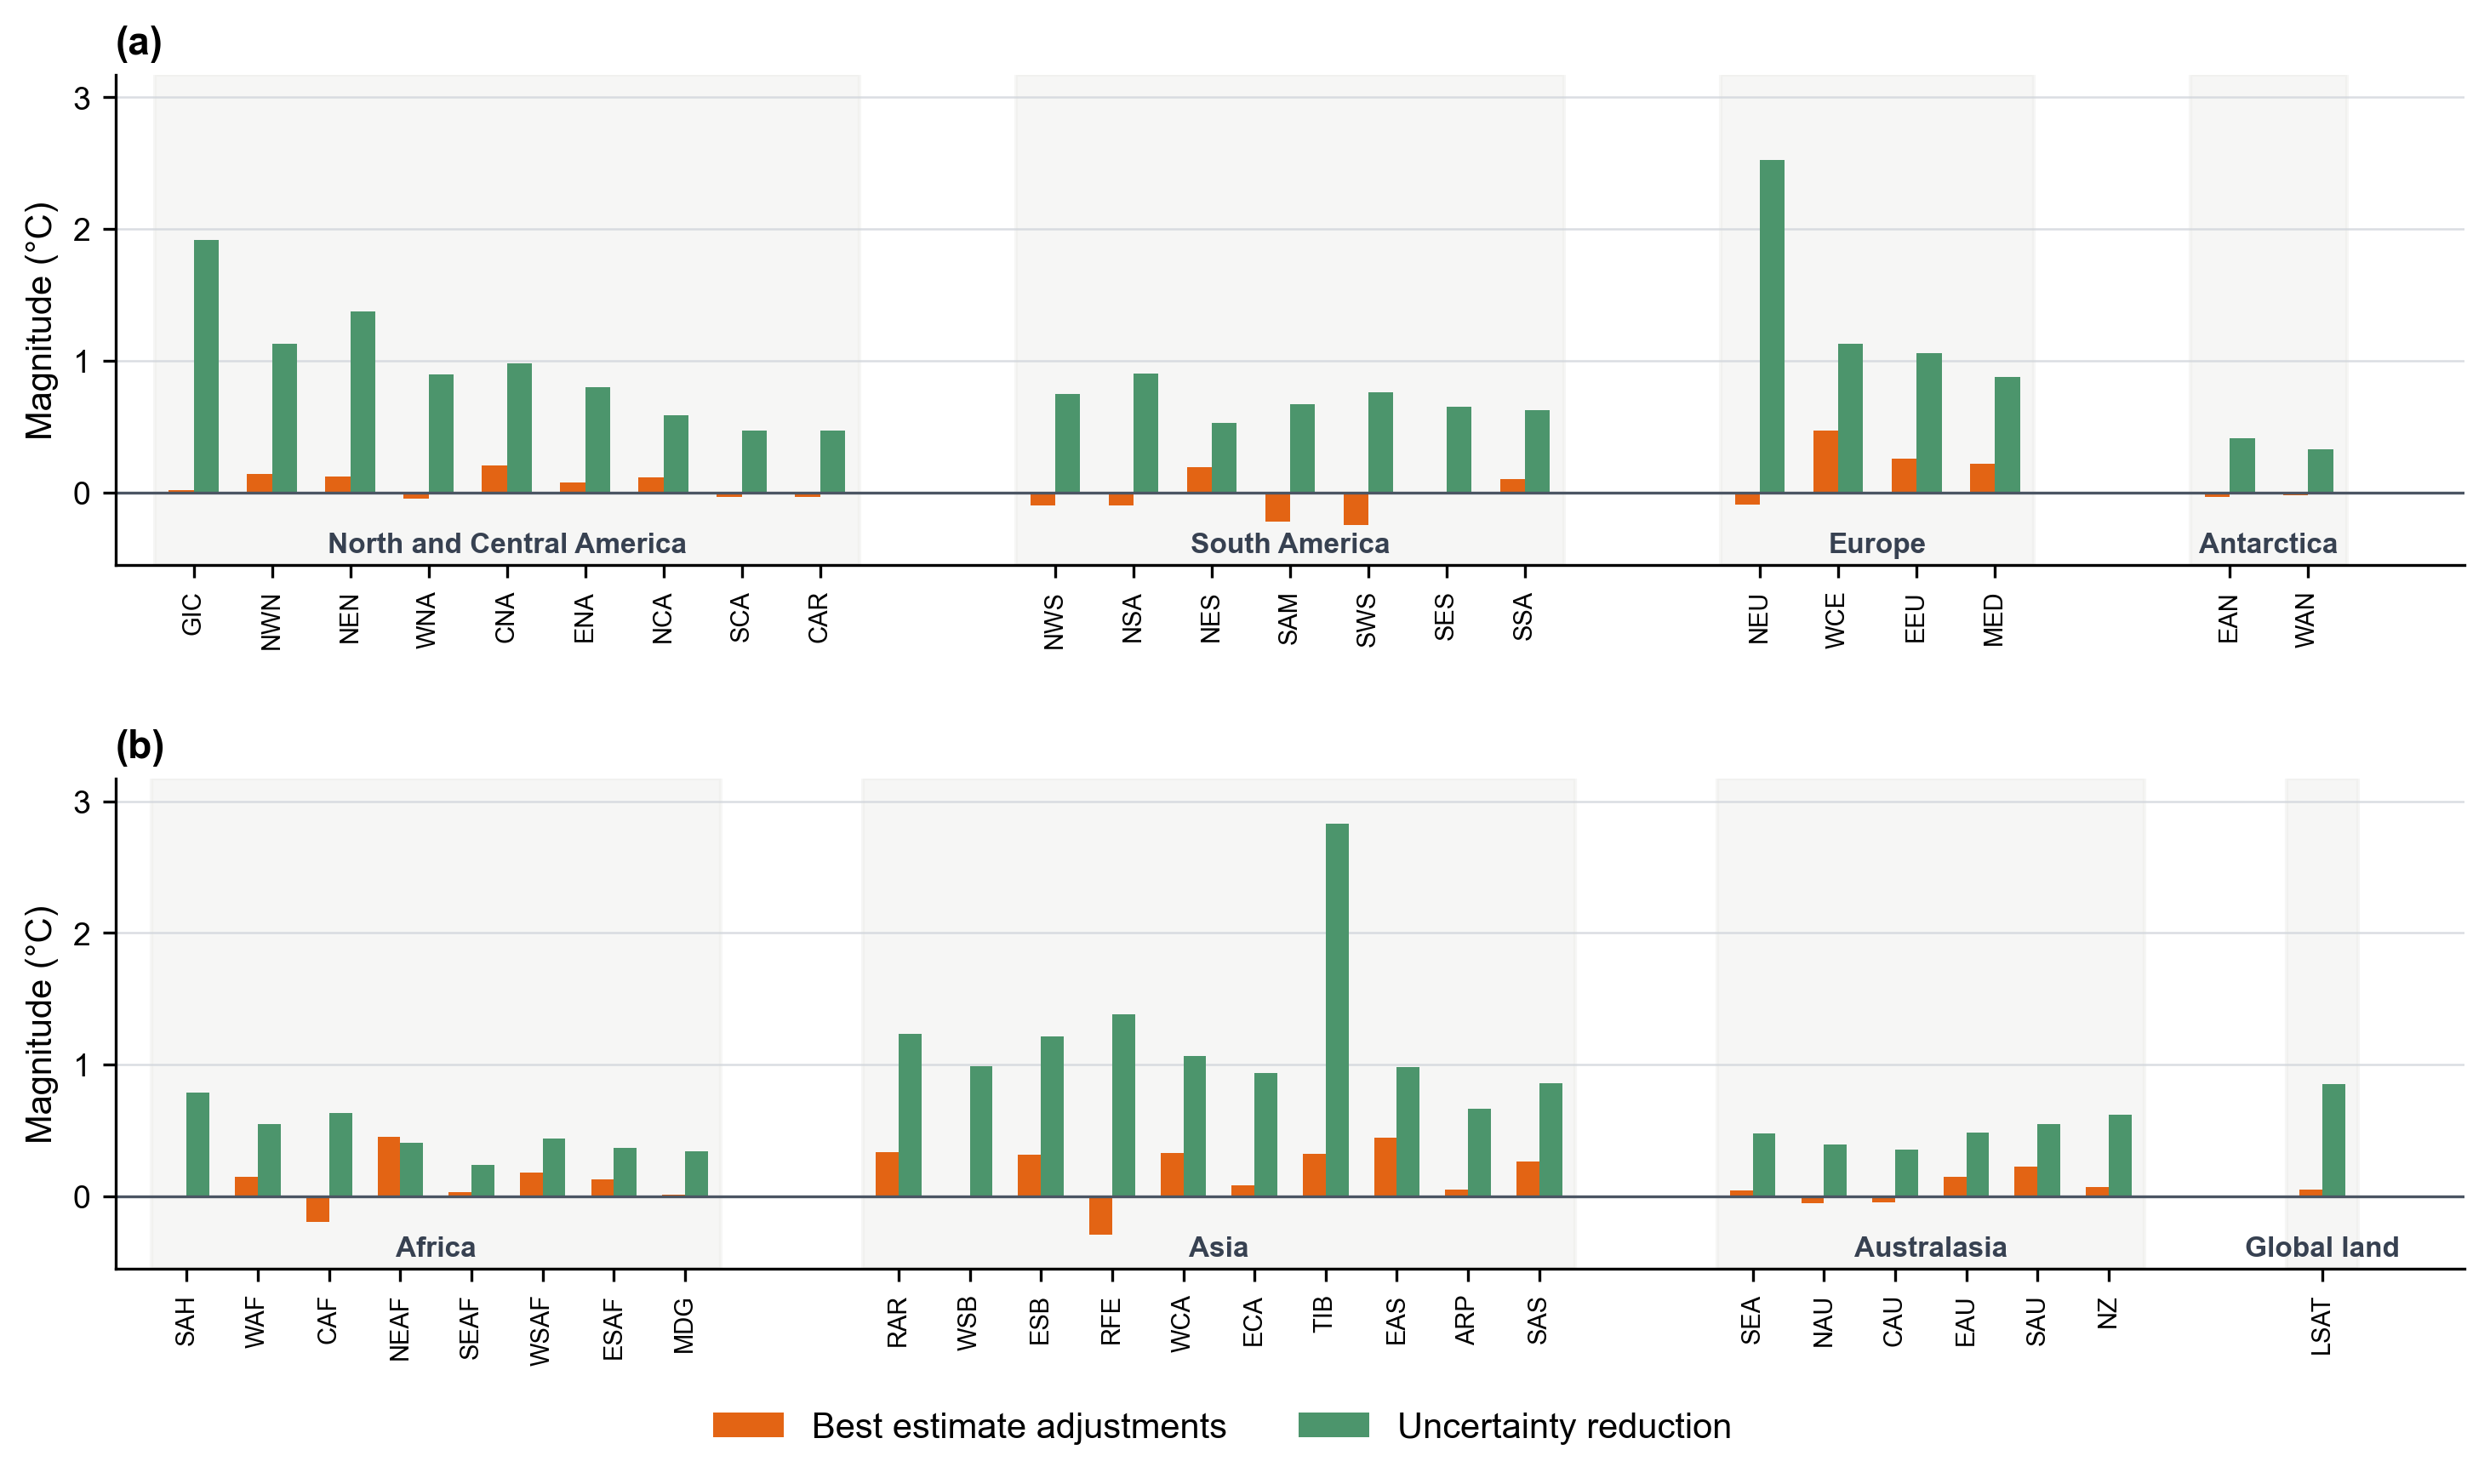

In [13]:
# Regional impact of the observational constraint, grouped as in the two-row regional panels.
# Both quantities are in degrees C, so a shared y-axis preserves their magnitude comparison.
bias_correction, uncertainty_reduction = xr.align(
    bias_correction, uncertainty_reduction, join='inner'
)

bias_values = bias_correction.values
uncertainty_values = uncertainty_reduction.values
region_abbrevs = (
    bias_correction['abbrevs'].values.astype(str)
    if 'abbrevs' in bias_correction.coords
    else bias_correction['region'].values.astype(str)
)
abbrev_to_index = {abbrev: idx for idx, abbrev in enumerate(region_abbrevs)}

continent_groups = {
    'North and Central America': ['GIC', 'NWN', 'NEN', 'WNA', 'CNA', 'ENA', 'NCA', 'SCA', 'CAR'],
    'South America': ['NWS', 'NSA', 'NES', 'SAM', 'SWS', 'SES', 'SSA'],
    'Europe': ['NEU', 'WCE', 'EEU', 'MED'],
    'Africa': ['SAH', 'WAF', 'CAF', 'NEAF', 'SEAF', 'WSAF', 'ESAF', 'MDG'],
    'Asia': ['RAR', 'WSB', 'ESB', 'RFE', 'WCA', 'ECA', 'TIB', 'EAS', 'ARP', 'SAS'],
    'Australasia': ['SEA', 'NAU', 'CAU', 'EAU', 'SAU', 'NZ'],
    'Antarctica': ['EAN', 'WAN'],
    'Global land': ['LSAT'],
}
continent_indices = {
    continent: [abbrev_to_index[abbrev] for abbrev in abbrevs if abbrev in abbrev_to_index]
    for continent, abbrevs in continent_groups.items()
}
row_groups = [
    {continent: continent_indices[continent] for continent in
     ['North and Central America', 'South America', 'Europe', 'Antarctica']},
    {continent: continent_indices[continent] for continent in
     ['Africa', 'Asia', 'Australasia', 'Global land']},
]

bar_width = 0.32
group_gap = 2
continent_label_y = -0.3
colors_metrics = {
    'Best estimate adjustments': '#e36414',
    'Uncertainty reduction': '#4C956C',
}
ymax = 1.12 * np.nanmax(np.concatenate([bias_values, uncertainty_values]))

def plot_regional_impact_panel(ax, grouped_indices, panel_label):
    x_ticks, x_labels = [], []
    current_x = 0
    for continent, indices in grouped_indices.items():
        for index in indices:
            ax.bar(current_x - bar_width / 2, bias_values[index], bar_width,
                   color=colors_metrics['Best estimate adjustments'], edgecolor='none',
                   label='Best estimate adjustments')
            ax.bar(current_x + bar_width / 2, uncertainty_values[index], bar_width,
                   color=colors_metrics['Uncertainty reduction'], edgecolor='none',
                   label='Uncertainty reduction')
            x_ticks.append(current_x)
            x_labels.append(region_abbrevs[index])
            current_x += 1
        current_x += group_gap

    current_x = 0
    for continent, indices in grouped_indices.items():
        group_width = len(indices)
        ax.axvspan(current_x - 0.5, current_x + group_width - 0.5,
                   color='#edede9', alpha=0.45, zorder=0)
        group_center = current_x + group_width / 2 - 0.5
        ax.text(group_center, continent_label_y, continent, ha='center', va='top',
                fontsize=8, fontweight='bold', color='#374151')
        current_x += group_width + group_gap

    ax.axhline(0, color='#4B5563', linewidth=0.8)
    ax.grid(axis='y', color='#D1D5DB', linewidth=0.6, alpha=0.8)
    ax.set_axisbelow(True)
    ax.set_ylim(-0.55, ymax)
    ax.set_xlim(-1, current_x - group_gap + 1)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, rotation=90, ha='center', fontsize=7)
    ax.set_ylabel('Magnitude (°C)', fontsize=10)
    ax.set_title(panel_label, loc='left', fontsize=11, fontweight='bold', pad=6)

with mpl.rc_context({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 9,
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
    'axes.spines.top': False,
    'axes.spines.right': False,
}):
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), dpi=300, sharey=True)
    plot_regional_impact_panel(axes[0], row_groups[0], '(a)')
    plot_regional_impact_panel(axes[1], row_groups[1], '(b)')

    handles, labels = axes[0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    fig.legend(by_label.values(), by_label.keys(), loc='lower center', ncol=2,
               frameon=False, fontsize=10, bbox_to_anchor=(0.5, 0.01))
    # fig.suptitle('Regional impact of the observational constraint',
    #              fontsize=14, fontweight='bold', y=0.995)
    fig.tight_layout(rect=(0, 0.06, 1, 0.98), h_pad=2.5)

    fig.savefig('../saved_figures/Fig.R1.pdf', dpi=300, bbox_inches='tight')
    plt.show()